# Linear Value Function Approximation

* **Represent the value function as a linear combination of features:**
$$\hat{V}(s, \mathbf{w}) = \mathbf{x}(s)^\top \mathbf{w} = \sum_{j=1}^{n} \mathbf{x}_j(s) \mathbf{w}_j$$

* **The objective function is quadratic with respect to $\mathbf{w}$:**
$$J(\mathbf{w}) = \mathbb{E}_\pi \left[ (V^\pi(s) - \mathbf{x}(s)^\top \mathbf{w})^2 \right]$$


In [1]:
import pandas as pd
import numpy as np

In [20]:
df = pd.read_csv('../data/ko.csv')

In [21]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-02-06,38.759998,38.939999,37.919998,38.029999,27.686878,22661500
1,2014-02-07,38.169998,38.349998,37.869999,37.950001,27.628639,20389000
2,2014-02-10,38.070000,38.619999,37.840000,38.570000,28.080019,20877200
3,2014-02-11,38.669998,38.779999,38.509998,38.639999,28.130970,15361300
4,2014-02-12,38.849998,38.919998,38.400002,38.509998,28.036333,10633400


In [22]:
print(f"{df.shape[0]} days")

2515 days


In [23]:
# expected return
alpha = 0.01

# days in month
days_in_month = 30

In [24]:
def calc_spread(df):
    return df['Close'] / df['Open'] - 1

def add_position_scores(df):
    # raw spread of each candlestick
    spread = calc_spread(df)
    
    df['score'] = spread

    return df


# add scores
df = add_position_scores(df)

In [25]:
def add_technical_indicators(df):
    o = df['Open']
    h = df['High']
    l = df['Low']
    c = df['Close']

    # ── 1. RSI (14) ──────────────────────────────────────────────────────────
    rsi_period = 14
    delta = c.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=rsi_period - 1, min_periods=rsi_period).mean()
    avg_loss = loss.ewm(com=rsi_period - 1, min_periods=rsi_period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    rsi.iloc[:rsi_period] = np.nan          # mask warm-up rows
    df['RSI'] = rsi / 100                   # already in [0,100] → divide by 100

    # ── 2. MACD histogram (12/26/9) ──────────────────────────────────────────
    macd_slow = 26
    ema_fast = c.ewm(span=12, min_periods=12).mean()
    ema_slow = c.ewm(span=macd_slow, min_periods=macd_slow).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=9, min_periods=9).mean()
    hist = macd_line - signal_line
    offset = macd_slow + 9 - 1
    hist.iloc[:offset] = np.nan
    # min-max normalise over the valid window
    h_min, h_max = hist.min(), hist.max()
    df['MACD_hist'] = (hist - h_min) / (h_max - h_min) if h_max != h_min else hist * 0

    # ── 3. Bollinger Band Width (20, 2σ) ─────────────────────────────────────
    bb_period = 20
    sma = c.rolling(bb_period).mean()
    std = c.rolling(bb_period).std()
    bb_width = (2 * 2 * std) / sma          # (upper - lower) / mid
    bb_width.iloc[:bb_period] = np.nan
    bw_min, bw_max = bb_width.min(), bb_width.max()
    df['BB_width'] = (bb_width - bw_min) / (bw_max - bw_min) if bw_max != bw_min else bb_width * 0

    # ── 4. ATR (14) ──────────────────────────────────────────────────────────
    atr_period = 14
    prev_c = c.shift(1)
    tr = pd.concat([
        h - l,
        (h - prev_c).abs(),
        (l - prev_c).abs()
    ], axis=1).max(axis=1)
    atr = tr.ewm(com=atr_period - 1, min_periods=atr_period).mean()
    atr.iloc[:atr_period] = np.nan
    atr_min, atr_max = atr.min(), atr.max()
    df['ATR'] = (atr - atr_min) / (atr_max - atr_min) if atr_max != atr_min else atr * 0

    # ── 5. Stochastic %K (14) ────────────────────────────────────────────────
    stoch_period = 14
    lowest_l  = l.rolling(stoch_period).min()
    highest_h = h.rolling(stoch_period).max()
    stoch_k = (c - lowest_l) / (highest_h - lowest_l).replace(0, np.nan) * 100
    stoch_k.iloc[:stoch_period] = np.nan
    df['Stoch_K'] = stoch_k / 100           # already in [0,100] → divide by 100

    offset = 35
    return df, offset

In [26]:
df, offset = add_technical_indicators(df)
df = df[offset:]

In [27]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,score,RSI,MACD_hist,BB_width,ATR,Stoch_K
35,2014-03-28,38.889999,39.029999,38.820000,38.950001,28.581339,11502100,0.001543,0.633663,0.587761,0.020346,0.033778,0.930436
36,2014-03-31,38.990002,39.029999,38.459999,38.660000,28.368536,24489800,-0.008464,0.558345,0.583349,0.018740,0.038141,0.678261
37,2014-04-01,38.529999,38.889999,38.310001,38.410000,28.185083,20515700,-0.003114,0.502857,0.574191,0.018245,0.042426,0.460869
38,2014-04-02,38.490002,38.540001,38.299999,38.330002,28.126387,15709100,-0.004157,0.486205,0.566247,0.018363,0.037093,0.391306
39,2014-04-03,38.389999,38.490002,38.040001,38.070000,27.935596,18114000,-0.008335,0.435707,0.555484,0.021599,0.037889,0.111110


In [28]:
# good trade spread day
trade_spread_idx = df.index[calc_spread(df) > alpha]

# count how many such days fall into each consecutive 30-row block
trade_spread_counts = (
    trade_spread_idx.to_series()
    .groupby(trade_spread_idx // days_in_month)
    .size()
)

# print trade frequency expectation
avg_trades_in_month = round(trade_spread_counts.mean())
print(f"{trade_spread_idx.size} days, {avg_trades_in_month} frequency in month")

# before good trade day (should buy position)
before_trade_spread_idx = trade_spread_idx - 1

# exclude negative positions
before_trade_spread_idx = before_trade_spread_idx[before_trade_spread_idx > offset]


250 days, 3 frequency in month


In [29]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

In [30]:
train_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,score,RSI,MACD_hist,BB_width,ATR,Stoch_K
35,2014-03-28,38.889999,39.029999,38.820000,38.950001,28.581339,11502100,0.001543,0.633663,0.587761,0.020346,0.033778,0.930436
36,2014-03-31,38.990002,39.029999,38.459999,38.660000,28.368536,24489800,-0.008464,0.558345,0.583349,0.018740,0.038141,0.678261
37,2014-04-01,38.529999,38.889999,38.310001,38.410000,28.185083,20515700,-0.003114,0.502857,0.574191,0.018245,0.042426,0.460869
38,2014-04-02,38.490002,38.540001,38.299999,38.330002,28.126387,15709100,-0.004157,0.486205,0.566247,0.018363,0.037093,0.391306
39,2014-04-03,38.389999,38.490002,38.040001,38.070000,27.935596,18114000,-0.008335,0.435707,0.555484,0.021599,0.037889,0.111110


In [31]:
def forecast(row):
    return row @ x

x_cols = ['RSI', 'MACD_hist', 'BB_width', 'ATR', 'Stoch_K']

# choose columns for A
A = train_df[x_cols].to_numpy()

# optional: add intercept term
A = np.column_stack([A])

B = train_df['score'].to_numpy()

# solve Ax ≈ B
x, residuals, rank, s = np.linalg.lstsq(A, B, rcond=None)

print(x)

[ 0.00228629 -0.01470687  0.0021073  -0.00485106  0.01382149]


In [32]:
A_test = test_df[x_cols].to_numpy()
A_test = np.column_stack([A_test])

pred = np.round(A_test @ x, 4)

In [33]:
test_result_df = pd.DataFrame({'pred': pred, 'score': test_df['score']})

In [34]:
test_result_df.head()

,pred,score
2019,-0.0019,-0.023960
2020,-0.0008,0.008644
2021,0.0002,-0.000820
2022,0.0002,0.000657
2023,0.0048,0.025929


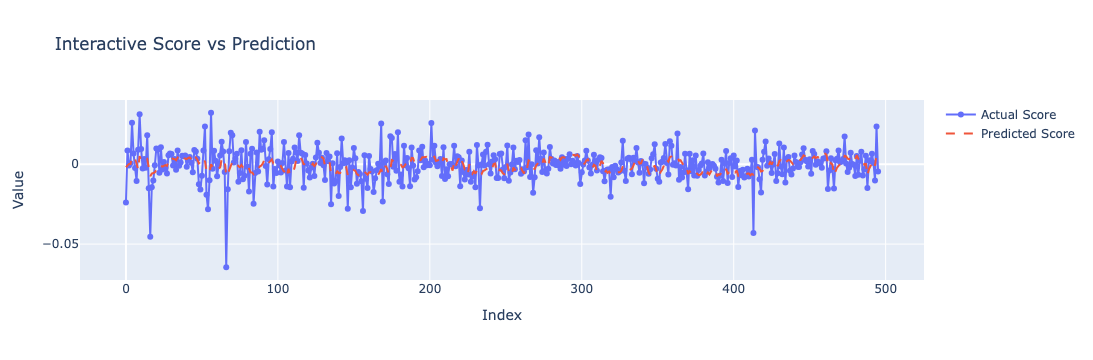

In [35]:
import plotly.graph_objects as go

fig = go.Figure()

# Add Actual Score
fig.add_trace(go.Scatter(y=test_result_df['score'], name='Actual Score', mode='lines+markers'))

# Add Predicted Score
fig.add_trace(go.Scatter(y=test_result_df['pred'], name='Predicted Score', mode='lines', line=dict(dash='dash')))

fig.update_layout(
    title='Interactive Score vs Prediction',
    xaxis_title='Index',
    yaxis_title='Value',
    hovermode='x unified' # Shows both values when you hover
)

fig.show()

/var/folders/rr/b11l3d051_s353y37p2zc9dc0000gn/T/ipykernel_46453/1796412327.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(loc='upper left', markerscale=2)
/var/folders/rr/b11l3d051_s353y37p2zc9dc0000gn/T/ipykernel_46453/1796412327.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


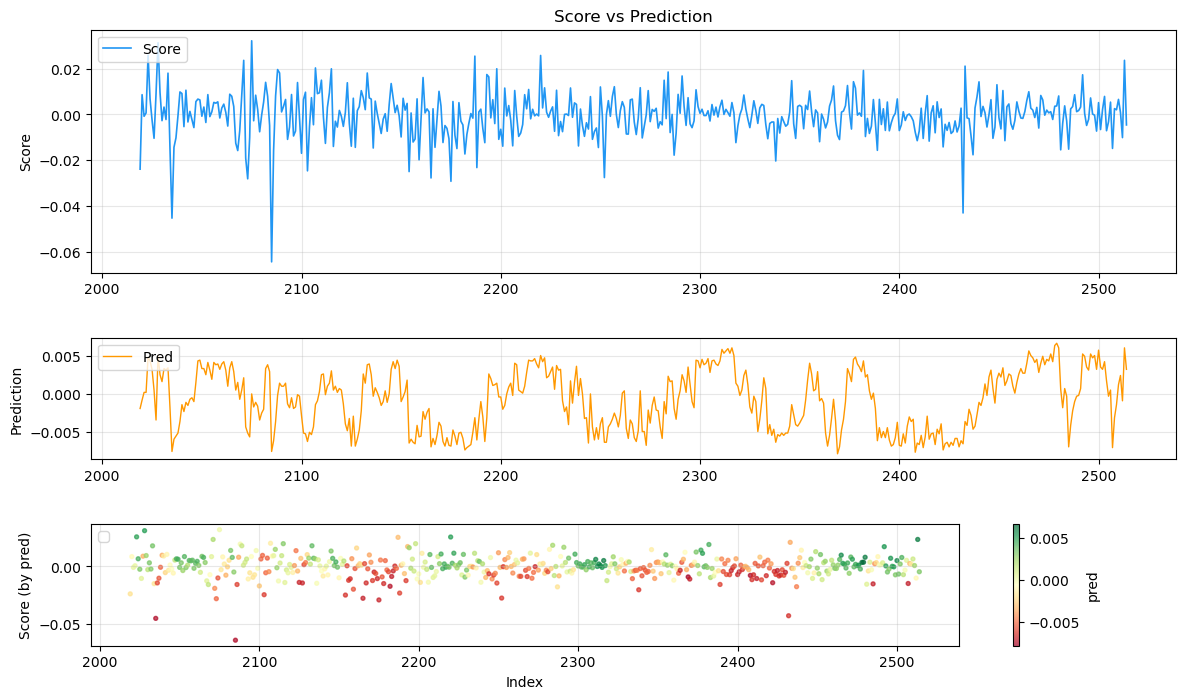

In [36]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_predictions(test_result_df):
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.4)

    # ── 1. Score over time ───────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(test_result_df.index, test_result_df['score'], 
             color='#2196F3', linewidth=1.2, label='Score')
    ax1.set_ylabel('Score')
    ax1.set_title('Score vs Prediction')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # ── 2. Prediction signal ─────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    unique_preds = sorted(test_result_df['pred'].unique())
    
    if len(unique_preds) <= 3:  # classification (e.g. -1, 0, 1)
        colors = {1: '#4CAF50', 0: '#9E9E9E', -1: '#F44336'}
        default_colors = ['#4CAF50', '#9E9E9E', '#F44336', '#FF9800', '#9C27B0']
        for i, val in enumerate(unique_preds):
            mask = test_result_df['pred'] == val
            color = colors.get(val, default_colors[i % len(default_colors)])
            ax2.scatter(test_result_df.index[mask], 
                       test_result_df['pred'][mask],
                       c=color, s=10, label=f'pred={val}', zorder=3)
        ax2.set_ylabel('Prediction')
        ax2.legend(loc='upper left', markerscale=2)
    else:  # regression
        ax2.plot(test_result_df.index, test_result_df['pred'],
                color='#FF9800', linewidth=1.0, label='Pred')
        ax2.set_ylabel('Prediction')
        ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    # ── 3. Overlay: score colored by prediction ──────────────────────────────
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    if len(unique_preds) <= 3:
        colors = {1: '#4CAF50', 0: '#9E9E9E', -1: '#F44336'}
        default_colors = ['#4CAF50', '#9E9E9E', '#F44336', '#FF9800', '#9C27B0']
        for i, val in enumerate(unique_preds):
            mask = test_result_df['pred'] == val
            color = colors.get(val, default_colors[i % len(default_colors)])
            ax3.scatter(test_result_df.index[mask],
                       test_result_df['score'][mask],
                       c=color, s=8, alpha=0.6, label=f'pred={val}')
    else:
        sc = ax3.scatter(test_result_df.index, test_result_df['score'],
                        c=test_result_df['pred'], cmap='RdYlGn', s=8, alpha=0.7)
        plt.colorbar(sc, ax=ax3, label='pred')
    ax3.set_ylabel('Score (by pred)')
    ax3.set_xlabel('Index')
    ax3.legend(loc='upper left', markerscale=2)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_predictions(test_result_df)